<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/fkkerplanck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Procurando solução...
P inicial = 5.730087398677564e-05

========== RESÍDUO DA EDO ==========
Erro máximo : 0.00048274583008300204
Erro médio  : 6.500922788711882e-06

========== COMPARAÇÃO DAS INTEGRAIS ==========
Erro máximo em A = 3.397048906805811e-05
Erro máximo em B = 4.4812286671726265e-06


/tmp/ipykernel_404/669010009.py:109: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_int[i] = np.trapz(P[i:],w[i:])


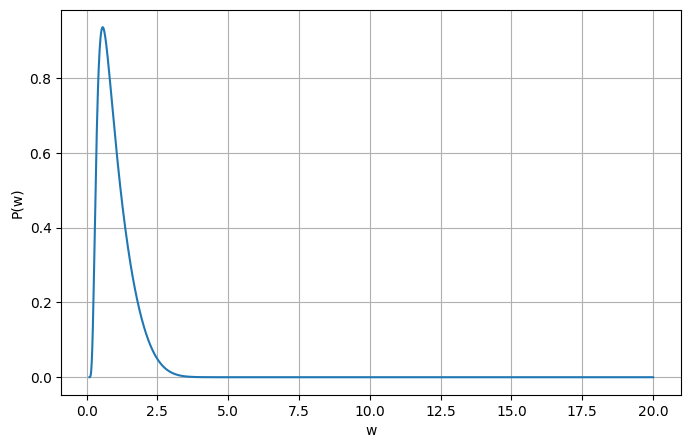

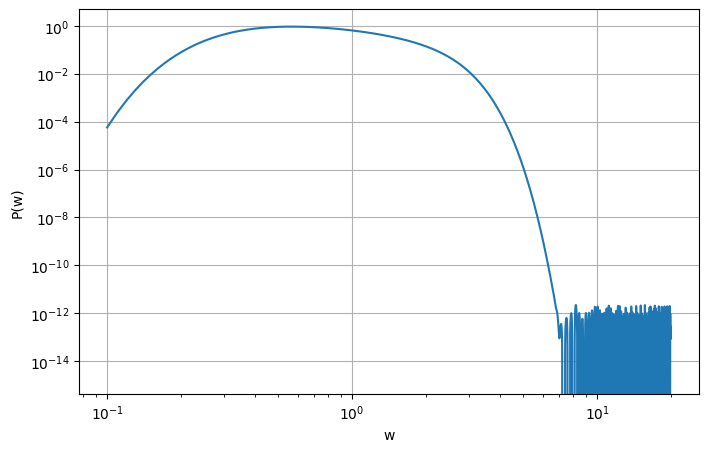

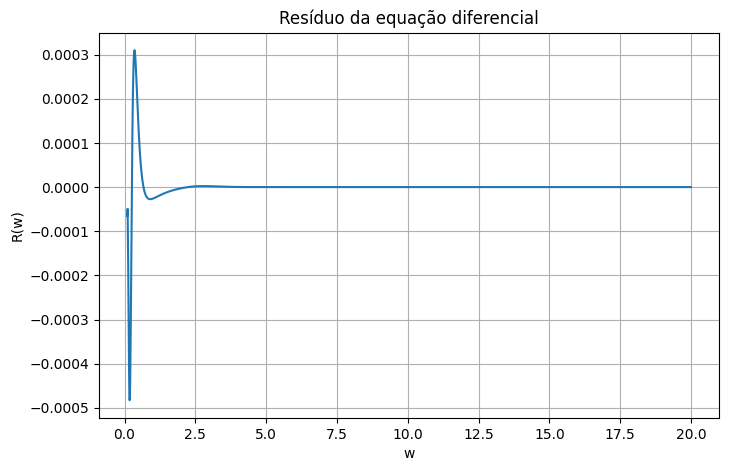

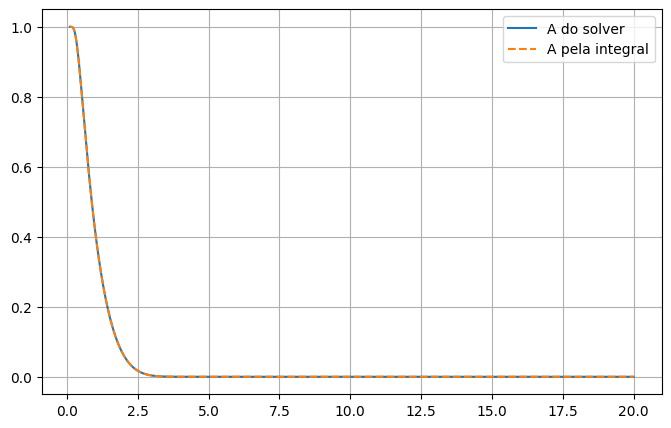

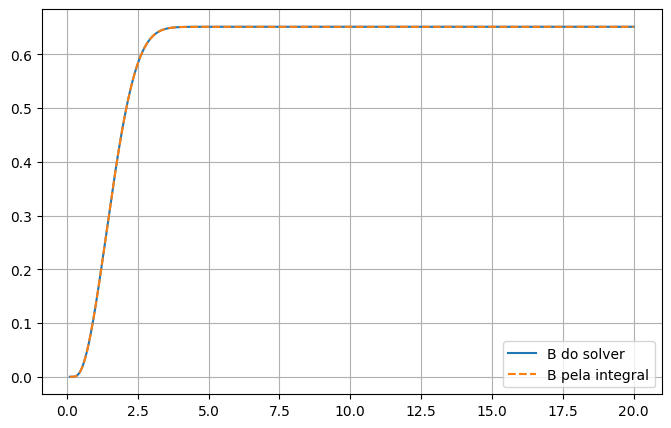

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.optimize import root_scalar

# ====================================================
# Parâmetros
# ====================================================

tau = 1.0
beta = 1.0

lam = tau/(beta**2)

w_start = 0.1
w_end = 20.0

# ====================================================
# Sistema de EDOs
# ====================================================

def model_odes(w,y):

    P,A,B = y

    denom = 0.5*w**2*A + B

    if denom <= 1e-15:
        denom = 1e-15

    dP = ((lam*(1-w)-w*A)/denom)*P
    dA = -P
    dB = 0.5*w**2*P

    return [dP,dA,dB]

# ====================================================
# Método do tiro
# ====================================================

def shoot(p0):

    y0 = [p0,1.0,0.0]

    sol = solve_ivp(
        model_odes,
        [w_start,w_end],
        y0,
        method="RK45",
        rtol=1e-10,
        atol=1e-12
    )

    return sol.y[1,-1]

print("Procurando solução...")

res = root_scalar(
    shoot,
    bracket=[1e-10,2],
    method="brentq"
)

p0 = res.root

print("P inicial =",p0)

# ====================================================
# Solução final
# ====================================================

sol = solve_ivp(
    model_odes,
    [w_start,w_end],
    [p0,1.0,0.0],
    t_eval=np.linspace(w_start,w_end,2000),
    rtol=1e-10,
    atol=1e-12
)

w = sol.t
P = sol.y[0]
A = sol.y[1]
B = sol.y[2]

# ====================================================
# Verificação da EDO original
# ====================================================

Q = (0.5*w**2*A + B)*P

dQ = np.gradient(Q,w)

R = (1-w)*P - dQ

print()
print("========== RESÍDUO DA EDO ==========")
print("Erro máximo :",np.max(np.abs(R)))
print("Erro médio  :",np.mean(np.abs(R)))

# ====================================================
# Reconstrução de A pela definição
# ====================================================

A_int = np.zeros_like(w)

for i in range(len(w)-1):

    A_int[i] = np.trapz(P[i:],w[i:])

# ====================================================
# Reconstrução de B pela definição
# ====================================================

B_int = cumulative_trapezoid(
    0.5*w**2*P,
    w,
    initial=0
)

# ====================================================
# Erro entre solver e integrais
# ====================================================

erroA = A-A_int
erroB = B-B_int

print()
print("========== COMPARAÇÃO DAS INTEGRAIS ==========")
print("Erro máximo em A =",np.max(np.abs(erroA)))
print("Erro máximo em B =",np.max(np.abs(erroB)))

# ====================================================
# Gráficos
# ====================================================

plt.figure(figsize=(8,5))
plt.plot(w,P)
plt.xlabel("w")
plt.ylabel("P(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.loglog(w,P)
plt.xlabel("w")
plt.ylabel("P(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,R)
plt.title("Resíduo da equação diferencial")
plt.xlabel("w")
plt.ylabel("R(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,A,label="A do solver")
plt.plot(w,A_int,"--",label="A pela integral")
plt.legend()
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,B,label="B do solver")
plt.plot(w,B_int,"--",label="B pela integral")
plt.legend()
plt.grid()

plt.show()